####     Arabic healthcare dataset is a large text dataset consisting of more than 808K questions and answers across 90 variant categories. It makes a great input for different Arabic NLP textual tasks. The dataset is scraped from “Altibbi”[8] medical website and is public and free to use.

## Libraries

In [1]:
import numpy as np
import pandas as pd
import re
from transformers import GPT2Tokenizer
from nltk.tokenize import word_tokenize
from pyarabic.araby import strip_diacritics, strip_tatweel

In [2]:
df = pd.read_excel('/kaggle/input/ahd-arabic-healthcare-dataset/AHD.xlsx')

In [3]:
df.head()

,Question,Answer,Category
0,اجريت صورة رنين مغناطيسي للثدي ظهر منطقة تعزيز...,المهم بالموضوع ما هي درجة ال BIRADS الموصوفة ل...,جراحة عامة
1,انا اعاني من اشياء تجبرني على فعل امور لا اريد...,الف سلامه عليك ، انت في حاجه الي معالج نفسي لم...,أمراض نفسية
2,أريد الاستفسار عن مضاعفات عملية استئصال ورم ال...,كغيرها من العمليات الجراحية ترتبط عملية استئصا...,أمراض الغدد الصماء
3,اليوم حاسس ان عندى حاجه فى الدبر من جوا مش عاي...,يغلب ان تعكس الحالة بواسير شرجية داخلية من الد...,جراحة عامة
4,ليه فجأة بحس انى مش عارفة اتنفس وجسمى بينمل وي...,من المحتمل عضوي او تاثير جانبي من اي ادويه بيت...,أمراض نفسية


## ****Dataset Describtion****

In [4]:
import pandas as pd
from tabulate import tabulate

# Group by Category and count
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Size']

# Calculate percentage
total = category_counts['Size'].sum()
category_counts['Percentage'] = (category_counts['Size'] / total * 100).round(2)

# Add index as No column
category_counts.insert(0, 'No', range(1, len(category_counts) + 1))

# Print the table with lines
print(tabulate(category_counts , headers='keys', tablefmt='grid', showindex=False))


+------+----------------------------------+--------+--------------+
|   No | Category                         |   Size |   Percentage |
+======+==================================+========+==============+
|    1 | أمراض نسائية                     | 162142 |        20.06 |
+------+----------------------------------+--------+--------------+
|    2 | الصحة الجنسية                    |  96398 |        11.92 |
+------+----------------------------------+--------+--------------+
|    3 | أمراض العضلات والعظام و المفاصل  |  45826 |         5.67 |
+------+----------------------------------+--------+--------------+
|    4 | أمراض المسالك البولية والتناسلية |  42599 |         5.27 |
+------+----------------------------------+--------+--------------+
|    5 | الأمراض الجلدية                  |  41760 |         5.17 |
+------+----------------------------------+--------+--------------+
|    6 | الطب العام                       |  41740 |         5.16 |
+------+----------------------------------+-----

#### AHD is considered one of the largest, available and variant Arabic datasets. It provides up to 90 categories with over 808k questions and answers, ensuring a strong foundation for precise text classification. The size of this dataset makes it an appropriate corpus for applying both classical and deep learning models. The dataset adopts the questions and answers with the same annotation as it appeared in the website. The average length of the questions and answers in the dataset is 115 and 152 respectively. It’s kept in a raw format with preprocessing or any type of cleaning.

## ****Data Preprocessing****

#### - remove any leading or trailing spaces
#### - remove tatweel
#### - remove diacritics
#### - remove any URL
#### - remove any character that is not an Arabic letter or whitespace
#### - applies text normalization

In [5]:
def preprocessing(text, remove_links=True, normalize_text=True):
    
    text = str(text).strip()                                                    # removes any leading or trailing spaces
    text = strip_tatweel(text)                                                  # removes tatweel
    text = strip_diacritics(text)                                               # removes diacritics
    if remove_links:                                                            
        text = re.sub(r'http[s]?://\S+', '', text)                              # removes any URL
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)                              # removes any character that is not an Arabic letter or whitespace
    if normalize_text:                                                          # applies text normalization
        text = text.replace('أ', 'ا').replace('إ', 'ا').replace('آ', 'ا').replace('ٱ', 'ا').replace('ة', 'ه').replace('?', '').replace('؟', '')
    return text

In [6]:
# Apply preprocessing
df.loc[:, 'Question'] = df['Question'].apply(preprocessing)
df.loc[:, 'Answer'] = df['Answer'].apply(preprocessing)


In [7]:
def remove_links(text):
    if isinstance(text, str):
        return text.split('للمزيد')[0].strip()
    return text

df['Answer'] = df['Answer'].apply(remove_links)

#### The dataset is highly imbalanced, with a significant disparity in category sizes. This imbalance can pose challenges in machine learning tasks. Merging similar categories in the dataset can significantly improve balance and model performance by reducing fragmentation. 
#### For instance, "أمراض نسائية" (Gynecological Diseases) now includes related topics such as "أمراض الحمل والولادة" (Pregnancy and Childbirth) and "جراحة نسائية" (Gynecological Surgery), ensuring that all aspects of women's health are treated as one category rather than separate, underrepresented ones.

In [8]:
# Define a dictionary for merging categories
category_mapping = {
    'أمراض نفسية': 'طبيب نفسي',
    'علم النفس': 'طبيب نفسي',
    'إدمان': 'طبيب نفسي',

    'أمراض الغدد الصماء': 'طبيب غدد صماء',
    'مرض السكري': 'طبيب غدد صماء',
    'هرمونات': 'طبيب غدد صماء',

    'أمراض نسائية': 'طبيب نساء وتوليد',
    'الحمل والولادة': 'طبيب نساء وتوليد',
    'جراحة نسائية': 'طبيب نساء وتوليد',
    'صحة المرأة': 'طبيب نساء وتوليد',

    'أمراض الجهاز الهضمي': 'طبيب جهاز هضمي',

    'أمراض القلب و الشرايين': 'طبيب قلب',
    'ارتفاع ضغط الدم': 'طبيب قلب',
    'جراحة القلب والشرايين': 'طبيب قلب',

    'الطب العام': 'طبيب باطني',
    'صحة عامة': 'طبيب باطني',
    'تشخيص': 'طبيب باطني',
    'صحة المسنين': 'طبيب باطني',
    'أمراض باطنية': 'طبيب باطني',

    'الأمراض الجلدية': 'طبيب جلدية',
    'البشرة والجمال': 'طبيب جلدية',

    'أمراض العضلات والعظام و المفاصل': 'طبيب عظام',
    'جراحة العظام': 'طبيب عظام',
    'علاج طبيعي': 'طبيب عظام',

    'أمراض الأطفال': 'طبيب أطفال',
    'صحة الطفل': 'طبيب أطفال',
    'علم الأجنة': 'طبيب أطفال',

    'أمراض الدم': 'طبيب أمراض دم',

    'امراض العيون': 'طبيب عيون',

    'تغذية': 'أخصائي تغذية',
    'فيتامينات و معادن': 'أخصائي تغذية',

    'الصحة الجنسية': 'طبيب مسالك بولية',
    'الأمراض الجنسية': 'طبيب مسالك بولية',
    'صحة الرجل': 'طبيب مسالك بولية',
    'أمراض المسالك البولية والتناسلية': 'طبيب مسالك بولية',
    'جراحة المسالك البولية': 'طبيب مسالك بولية',

    'أنف، أذن وحنجرة': 'طبيب أنف وأذن وحنجرة',

    'الأورام الخبيثة والحميدة': 'طبيب أورام',

    'الأمراض العصبية': 'طبيب أعصاب',
    'جراحة الأعصاب': 'طبيب أعصاب',

    'جراحة عامة': 'طبيب جراح',
    'جراحة تجميل': 'طبيب تجميل',
    'جراحة الأطفال': 'طبيب جراح',
    'جراحة الأوعية الدموية': 'طبيب جراح',

    'أمراض الأسنان': 'طبيب أسنان',
    'صحة الأسنان': 'طبيب أسنان',
    'طب الأسنان': 'طبيب أسنان',
    'جراحة الفك والأسنان': 'طبيب أسنان',
    'أمراض الفم': 'طبيب أسنان',
    
    'أمراض الجهاز التنفسي': 'طبيب صدرية',
    'الامراض المعدية': 'طبيب صدرية',

    'الصحة النفسية': 'طبيب نفسي',


    
}

# Apply the mapping to merge categories
df['Category'] = df['Category'].map(category_mapping).fillna(df['Category'])

# Check the updated category distribution
print(df['Category'].value_counts())


Category
طبيب نساء وتوليد        184773
طبيب مسالك بولية        165360
طبيب باطني               62443
طبيب عظام                50438
طبيب جلدية               48416
طبيب جهاز هضمي           36554
طبيب أطفال               32154
طبيب نفسي                31737
طبيب أسنان               28196
طبيب قلب                 27145
طبيب عيون                18682
طبيب أنف وأذن وحنجرة     18674
طبيب جراح                17376
طبيب غدد صماء            16624
أخصائي تغذية             16494
علم الصيدلة              14890
طبيب أورام               12361
طبيب أعصاب               11438
طبيب صدرية                6505
طبيب أمراض دم             2362
طبيب تجميل                1579
الصحة و الرياضة           1114
أرجية حساسية               555
أعشاب طبية                 402
الطب البديل                387
العقم                      386
مختبر                      224
الامراض الوراثية           166
علم المناعة                 92
علم الأشعة                  83
بصريات                      82
خدمات طبية                  77

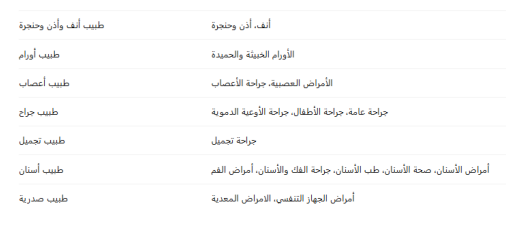

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/kaggle/input/gpppic1/1.png')

plt.imshow(img)
plt.axis('off')  # Hide axis
plt.show()


#### After merging the categories, some still have very few examples, especially those with less than 400 rows. Removing these small categories will help the model perform better. When a category has too little data, the model struggles to learn from it and might make random or incorrect predictions.

In [10]:
# Categories to be removed
categories_to_remove = [
    'مختبر', 'علم الصيدلة', 'علم الأمراض', 'أعشاب طبية', 'الطب البديل', 'بصريات',
    'علم الأشعة', 'خدمات طبية', 'إسعاف أولي', 'علم التشريح', 'علم السموم', 'تاريخ الطب',
    'أرجية حساسية', 'الامراض الوراثية', 'الصحة و الرياضة', 'علم المناعة', 'تشوهات خلقية',
    'مطاعيم و لقاحات', 'كيمياء', 'العقم', 'الطب الوقائي', 'حمل الأنابيب', 'رمضان',
    'أمراض الاستقلاب', 'تخدير', 'أخبار الطبي', 'تجهيزات طبية', 'علم النبات',
    'كيمياء عضوية', 'علم الأحياء', 'علم الوراثة', 'علم البيئة', 'كيمياء حيوية',
    'علم الأحياء الدقيقة', 'علم الأنسجة', 'فيزيولوجيا', 'فيزياء' , 'الأمراض الرثويه'
]

# Remove these categories from the dataframe
df = df[~df['Category'].isin(categories_to_remove)]

# Check the updated category distribution
print(df['Category'].value_counts())


Category
طبيب نساء وتوليد        184773
طبيب مسالك بولية        165360
طبيب باطني               62443
طبيب عظام                50438
طبيب جلدية               48416
طبيب جهاز هضمي           36554
طبيب أطفال               32154
طبيب نفسي                31737
طبيب أسنان               28196
طبيب قلب                 27145
طبيب عيون                18682
طبيب أنف وأذن وحنجرة     18674
طبيب جراح                17376
طبيب غدد صماء            16624
أخصائي تغذية             16494
طبيب أورام               12361
طبيب أعصاب               11438
طبيب صدرية                6505
طبيب أمراض دم             2362
طبيب تجميل                1579
Name: count, dtype: int64


#### Given the large size of the dataset, training a model on the entire corpus at once is computationally expensive and time-consuming. To address this, a subset was chosen that is more than 100k rows with answer lengths between 65-350 tokens, which results in better generalization, better performance for rare classes and higher generation.


In [11]:
# Define sampling fraction
sampling_fraction = 0.04
num_splits = 5

# To store all 5 subsets
subsets = []

# For each split
for split in range(num_splits):
    print(f"Creating subset {split + 1}...")
    split_subset = pd.DataFrame()
    
    for category in df['Category'].unique():
        category_data = df[df['Category'] == category]
        
        # Sample size calculation
        sample_size = int(len(category_data) * sampling_fraction)
        if sample_size < 1000:
            sample_size = min(len(category_data), 1000)
        
        # Sample differently each time by changing the random seed
        sampled_data = category_data.sample(sample_size, random_state=42 + split)
        split_subset = pd.concat([split_subset, sampled_data])
    
    split_subset.reset_index(drop=True, inplace=True)
    subsets.append(split_subset)

# Example: check distribution in the first subset
print(subsets[0]['Category'].value_counts())


Creating subset 1...
Creating subset 2...
Creating subset 3...
Creating subset 4...
Creating subset 5...
Category
طبيب نساء وتوليد        7390
طبيب مسالك بولية        6614
طبيب باطني              2497
طبيب عظام               2017
طبيب جلدية              1936
طبيب جهاز هضمي          1462
طبيب أطفال              1286
طبيب نفسي               1269
طبيب أسنان              1127
طبيب قلب                1085
طبيب جراح               1000
طبيب أورام              1000
طبيب أنف وأذن وحنجرة    1000
طبيب صدرية              1000
طبيب أعصاب              1000
أخصائي تغذية            1000
طبيب عيون               1000
طبيب أمراض دم           1000
طبيب غدد صماء           1000
طبيب تجميل              1000
Name: count, dtype: int64


#### Preprocessing the dataset for NLP tasks is crucial to enhance the model’s performance. Tokenization, the process of breaking text into smaller units such as words or subwords, plays a key role in structuring the text efficiently for machine learning models.

In [12]:
def tokenize_text(text):
    # Tokenizing the Arabic text using NLTK (you can use another tokenizer if needed)
    return word_tokenize(text)

In [13]:
# Apply tokenization to all subsets
for i in range(len(subsets)):
    subsets[i]['Tokenized_Question'] = subsets[i]['Question'].apply(tokenize_text)
    subsets[i]['Tokenized_Answer'] = subsets[i]['Answer'].apply(tokenize_text)


In [14]:
# Remove duplicates
for i in range(len(subsets)):
    subsets[i] = subsets[i].drop_duplicates(subset=['Question', 'Answer']).reset_index(drop=True)


In [15]:
max_tokens = 512  

def handle_length(text, max_tokens):
    return text[:max_tokens] if len(text) > max_tokens else text

for i in range(len(subsets)):  # or disjoint_subsets
    subsets[i]['Processed_Question'] = subsets[i]['Tokenized_Question'].apply(lambda x: handle_length(x, max_tokens))
    subsets[i]['Processed_Answer'] = subsets[i]['Tokenized_Answer'].apply(lambda x: handle_length(x, max_tokens))


In [16]:
for i in range(len(subsets)):  # or disjoint_subsets
    subsets[i]['Question_with_Category'] = "[CATEGORY: " + subsets[i]['Category'] + "] " + subsets[i]['Processed_Question'].apply(lambda x: ' '.join(x))
    subsets[i]['Answer_with_Category'] = "[CATEGORY: " + subsets[i]['Category'] + "] " + subsets[i]['Processed_Answer'].apply(lambda x: ' '.join(x))


####  Another essential preprocessing step is removing stop words, which are common words that do not contribute significantly to meaning, such as "في" (in) or "من" (from). Arabic stop words are particularly important to remove because they consume unnecessary token space, reducing model efficiency.

In [17]:
# Manually defined Arabic stopwords
arabic_stopwords = [
    "في", "على", "من", "إلى", "أن", "أنها", "هو", "هي", "لا", "أنت", "أنا", 
    "و", "أو", "لكن", "إلخ", "هذا", "تلك", "إن", "لقد", "كانت", "كون", "بين"
]

# Function to remove stopwords
def remove_stopwords(text):
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in arabic_stopwords]
    return " ".join(filtered_tokens)

# Apply to all subsets
for i in range(len(subsets)):  # or disjoint_subsets
    subsets[i]['Cleaned_Question'] = subsets[i]['Question_with_Category'].apply(remove_stopwords)
    subsets[i]['Cleaned_Answer'] = subsets[i]['Answer_with_Category'].apply(remove_stopwords)


In [18]:
for i in range(len(subsets)):  # or disjoint_subsets
    subsets[i] = subsets[i].dropna(subset=['Cleaned_Question', 'Cleaned_Answer']).reset_index(drop=True)


In [19]:
# Display the shape of the cleaned and processed dataset
print(f"Shape of the cleaned dataset: ")

# Optionally, you can view the first few rows
print(subsets[0].head())
print(subsets[1].head())

Shape of the cleaned dataset: 
                                            Question  \
0  عملت عمليه الناسور العصعصي قبل سنه بالطريقه ال...   
1  ارجوكم ماهي اعراض سرطان الاثنى عشري اصبت بقرحه...   
2  سلام عليكم ظهر لي منء مده كتله صغيره مثل حبه ا...   
3  اختي ظهر لها انتفاخ في فتحه الشرج ولكنه  يسبب ...   
4  عملت عمليه افتاق اربي منذ سنه وشهرين  لقد عاود...   

                                              Answer   Category  \
0  حدوث نخزات بسيطه وارد الحدوث مكان العمليه، ينص...  طبيب جراح   
1  بعلم الطب كل شي واردلكنني لم اسمع بقرحه اثناعش...  طبيب جراح   
2  و عليكم السلام غالبا هذه الكتله سطحيه ولا علاق...  طبيب جراح   
3  دائما نؤكدعلى ضروره مراجعه طبيب الجراحه للكشف ...  طبيب جراح   
4  انصحك بالذهاب لطبيب الجراحه العامه للفحصومن ال...  طبيب جراح   

                                  Tokenized_Question  \
0  [عملت, عمليه, الناسور, العصعصي, قبل, سنه, بالط...   
1  [ارجوكم, ماهي, اعراض, سرطان, الاثنى, عشري, اصب...   
2  [سلام, عليكم, ظهر, لي, منء, مده, كتله, صغيره, ...   
3  [ا

In [20]:
import os

# Make sure the output directory exists
output_dir = "/kaggle/working/cleaned_subsets"
os.makedirs(output_dir, exist_ok=True)

# Save each subset as a separate CSV
for i, subset in enumerate(subsets):  # or disjoint_subsets
    file_path = os.path.join(output_dir, f"subset_{i+1}.csv")
    subset.to_csv(file_path, index=False)

print("✅ All subsets saved to:", output_dir)


✅ All subsets saved to: /kaggle/working/cleaned_subsets
